In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split

In [2]:
metadata = pd.read_csv('meta_bhak.csv', sep=';', index_col=0)

In [3]:
metadata

,Age (years),Gender,Condition
acc,,,
SRR9190548,36,Female,MDD
SRR9190515,27,Male,Healthy
SRR9190731,44,Female,SA
SRR9190772,51,Male,MDD
SRR9190614,23,Female,Healthy
...,...,...,...
SRR9190717,26,Female,Healthy
SRR9190489,40,Female,SA
SRR9190576,32,Male,SA


In [4]:
df = pd.read_csv('train_multi_omics_bhak.csv', sep=';', index_col=0)

In [5]:
df

,SRR9190548,SRR9190515,SRR9190731,SRR9190772,SRR9190614,SRR9190663,SRR9190471,SRR9190536,SRR9190732,SRR9190612,...,SRR9190729,SRR9190475,SRR9190715,SRR9190549,SRR9190788,SRR9190717,SRR9190489,SRR9190576,SRR9190524,SRR9190563
index,,,,,,,,,,,,,,,,,,,,,
10_100007315,6.190000e-01,5.650000e-01,7.690000e-01,4.480000e-01,7.860000e-01,6.920000e-01,8.180000e-01,8.000000e-01,5.620000e-01,1.000000e+00,...,5.000000e-01,6.920000e-01,1.000000e+00,6.920000e-01,6.150000e-01,9.230000e-01,8.080000e-01,8.180000e-01,6.470000e-01,5.000000e-01
10_100007385,7.440000e-01,6.790000e-01,8.000000e-01,5.120000e-01,9.170000e-01,8.330000e-01,6.110000e-01,8.570000e-01,8.180000e-01,9.600000e-01,...,7.500000e-01,8.260000e-01,5.760000e-01,7.180000e-01,9.330000e-01,5.380000e-01,6.590000e-01,7.080000e-01,8.570000e-01,8.850000e-01
10_100007391,9.250000e-01,8.570000e-01,8.500000e-01,9.070000e-01,9.730000e-01,9.500000e-01,8.820000e-01,8.570000e-01,8.710000e-01,9.660000e-01,...,8.850000e-01,8.000000e-01,8.680000e-01,7.950000e-01,9.380000e-01,7.410000e-01,8.040000e-01,8.390000e-01,9.230000e-01,9.580000e-01
10_100007439,8.410000e-01,9.060000e-01,8.000000e-01,7.230000e-01,9.530000e-01,7.080000e-01,9.200000e-01,8.890000e-01,9.520000e-01,8.710000e-01,...,9.690000e-01,8.570000e-01,9.530000e-01,8.330000e-01,9.130000e-01,7.710000e-01,9.260000e-01,8.410000e-01,8.890000e-01,9.330000e-01
10_100007596,9.220000e-01,9.430000e-01,9.380000e-01,9.270000e-01,9.470000e-01,8.810000e-01,8.890000e-01,8.920000e-01,8.540000e-01,9.490000e-01,...,9.680000e-01,9.740000e-01,9.250000e-01,9.810000e-01,9.410000e-01,9.210000e-01,7.920000e-01,9.050000e-01,1.000000e+00,9.750000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000232124,1.307968e-07,1.514359e-07,6.166738e-08,1.672153e-07,0.000000e+00,9.767794e-08,1.018774e-07,1.792918e-07,1.725998e-07,0.000000e+00,...,0.000000e+00,1.286845e-07,1.212443e-07,9.758751e-08,8.825003e-08,7.140684e-08,1.021776e-07,8.208128e-08,1.390490e-07,1.825734e-07
ENSG00000227999,1.307968e-07,1.730696e-07,0.000000e+00,2.866548e-07,8.277269e-08,1.627966e-08,1.867752e-07,4.482295e-08,1.725998e-07,1.362196e-07,...,4.603947e-07,1.103010e-07,1.616591e-07,1.366225e-07,4.412502e-08,3.570342e-07,3.576214e-07,8.208128e-08,1.853987e-07,1.643161e-07
ENSG00000232539,1.307968e-07,0.000000e+00,0.000000e+00,7.166371e-08,2.276249e-07,1.302373e-07,1.867752e-07,1.120574e-07,2.157497e-07,1.556795e-07,...,8.632400e-08,7.353398e-08,1.414517e-07,7.807001e-08,2.426876e-07,1.249620e-07,1.277219e-07,1.231219e-07,0.000000e+00,1.825734e-08


In [6]:
X = df.T

In [7]:
samples = X.index.intersection(metadata.index)

In [8]:
X = X.loc[samples]
y = metadata.loc[samples, 'Age (years)']

In [9]:
X = X.astype('float32')

In [10]:
y

SRR9190548    36
SRR9190515    27
SRR9190731    44
SRR9190772    51
SRR9190614    23
              ..
SRR9190717    26
SRR9190489    40
SRR9190576    32
SRR9190524    27
SRR9190563    21
Name: Age (years), Length: 182, dtype: int64

In [11]:
X.isnull().sum()

index
10_100007315       0
10_100007385       0
10_100007391       0
10_100007439       0
10_100007596       0
                  ..
ENSG00000232124    0
ENSG00000227999    0
ENSG00000232539    0
ENSG00000234509    0
ENSG00000215386    0
Length: 2605224, dtype: int64

In [12]:
y.isnull().sum()

np.int64(0)

In [13]:
def horvath_transform(age, adult_age=20):
    age = np.array(age)
    return np.where(age <= adult_age, np.log(age+1)-np.log(adult_age + 1), (age - adult_age)/(adult_age+1))

In [14]:
def horvath_inverse(transformed_age, adult_age=20):
    transformed_age = np.array(transformed_age)
    return np.where(transformed_age < 0, np.exp(transformed_age + np.log(adult_age+1))-1, transformed_age * (adult_age+1) + adult_age)

In [15]:
y_transformed = horvath_transform(y)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

In [17]:
model = ElasticNetCV(
    l1_ratio=[0.9, 1.0],
    cv=3,
    alphas=50,
    n_jobs=8,
    max_iter=5000,
    random_state=42
)
model.fit(X_train, y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.9, 1.0]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",50
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [18]:
preds_transformed = model.predict(X_test)
preds_years = horvath_inverse(preds_transformed)
actual_years = horvath_inverse(y_test)

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(actual_years, preds_years)
r2 = r2_score(actual_years, preds_years)

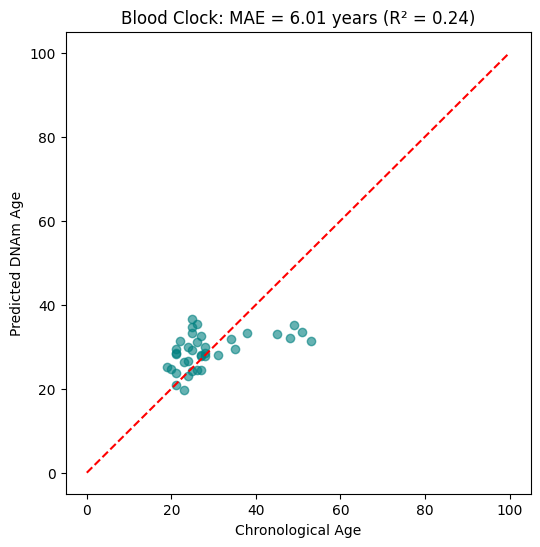

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(actual_years, preds_years, alpha=0.6, color='teal')
plt.plot([0, 100], [0, 100], 'r--')
plt.title(f"Blood Clock: MAE = {mae:.2f} years (R² = {r2:.2f})")
plt.xlabel("Chronological Age")
plt.ylabel("Predicted DNAm Age")
plt.show()